In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('Customer Churn.csv')
df.head(10)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [9]:
# Use the correct capitalization: "TotalCharges"
df["TotalCharges"] = df["TotalCharges"].replace(" ", "0")
df["TotalCharges"] = df["TotalCharges"].astype(float)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [11]:
df.isnull().sum().sum()

np.int64(0)

In [12]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [13]:
df.duplicated().sum()

np.int64(0)

In [16]:
df["customerID"].duplicated().sum()

np.int64(0)

In [18]:
def con(value):
    if value==1:
        return "yes"
    else:
        return "no"
df['SeniorCitizen'] = df['SeniorCitizen'].map({1: 'yes', 0: 'no'})

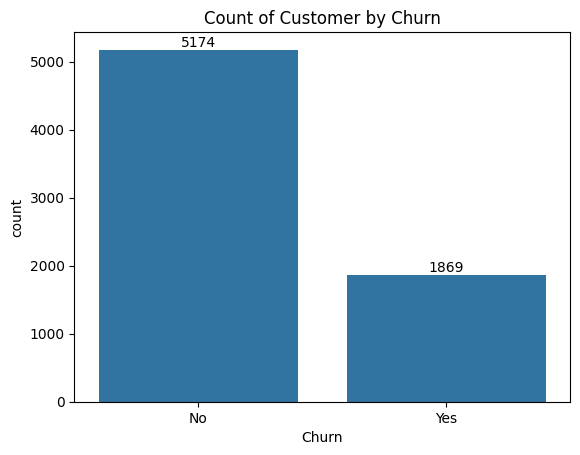

In [30]:
ax = sns.countplot(x= 'Churn',data=df)
ax.bar_label(ax.containers[0])
plt.title("Count of Customer by Churn")
plt.show()

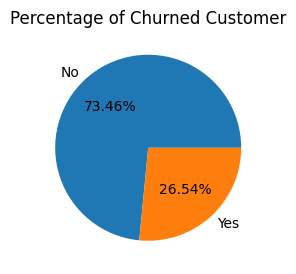

In [31]:
plt.figure(figsize = (3,4))
gb= df.groupby("Churn").agg({'Churn':"count"})
plt.pie(gb['Churn'], labels=gb.index, autopct = "%1.2f%%")
plt.title("Percentage of Churned Customer")
plt.show()

#from the given pie chart we can conclude that 26.54% of custome have churned out
# now explore the reason behind it

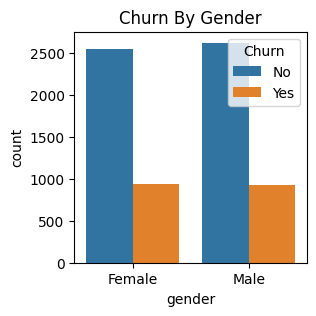

In [37]:
plt.figure(figsize = (3,3))
sns.countplot(x=df["gender"], data = df, hue="Churn")
plt.title("Churn By Gender")
plt.show()

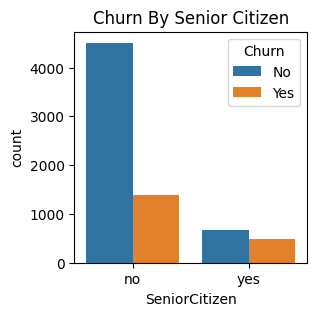

In [39]:
plt.figure(figsize = (3,3))
sns.countplot(x=df["SeniorCitizen"], data = df, hue="Churn")
plt.title("Churn By Senior Citizen")
plt.show()

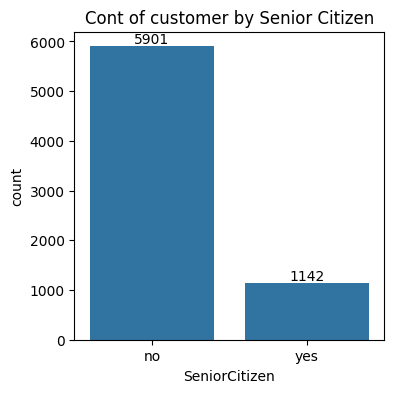

In [43]:
plt.figure(figsize = (4,4))
ax = sns.countplot(x=df["SeniorCitizen"], data = df)
ax.bar_label (ax.containers[0])
plt.title("Cont of customer by Senior Citizen")
plt.show()

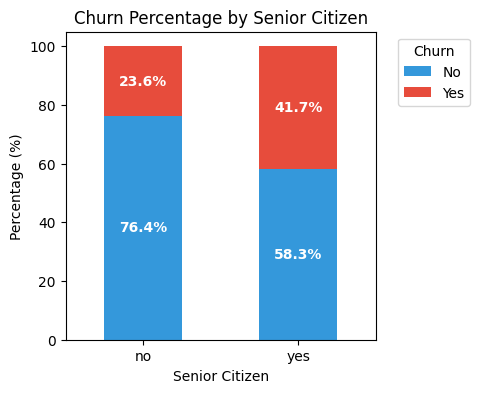

In [44]:
# 1. Create a percentage crosstab
# 'index' normalization gives the % of Churn for each SeniorCitizen category
ct = pd.crosstab(df['SeniorCitizen'], df['Churn'], normalize='index') * 100

# 2. Plot as a stacked bar
ax = ct.plot(kind='bar', stacked=True, figsize=(4,4), color=['#3498db', '#e74c3c'])

# 3. Add percentage labels inside the bars
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy() 
    if height > 0:
        ax.text(x + width/2, 
                y + height/2, 
                f'{height:.1f}%', 
                ha='center', 
                va='center',
                color='white',
                fontweight='bold')

plt.title("Churn Percentage by Senior Citizen")
plt.xlabel("Senior Citizen")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.legend(title='Churn', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# Comparitive a greater percentage of peopple in senior citizen category have Churned.

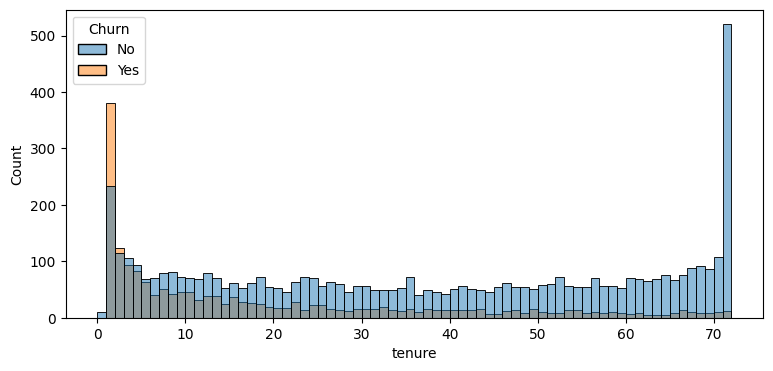

In [50]:
plt.figure(figsize = (9,4))
sns.histplot(x = "tenure", data = df, bins = 72, hue='Churn')
plt.show()

#people who have used our serives for a long time have stayed and people who have used our services for short time have churned

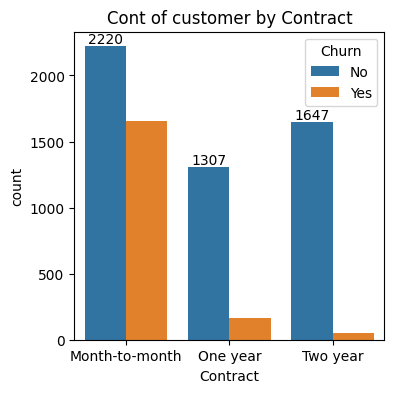

In [52]:
plt.figure(figsize = (4,4))
ax = sns.countplot(x=df["Contract"], data = df, hue= 'Churn')
ax.bar_label (ax.containers[0])
plt.title("Cont of customer by Contract")
plt.show()

# People who have month ot month contract are more likely to churn than who have 1 or 2 year contract

In [54]:
df.columns.values

array(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges',
       'TotalCharges', 'Churn'], dtype=object)

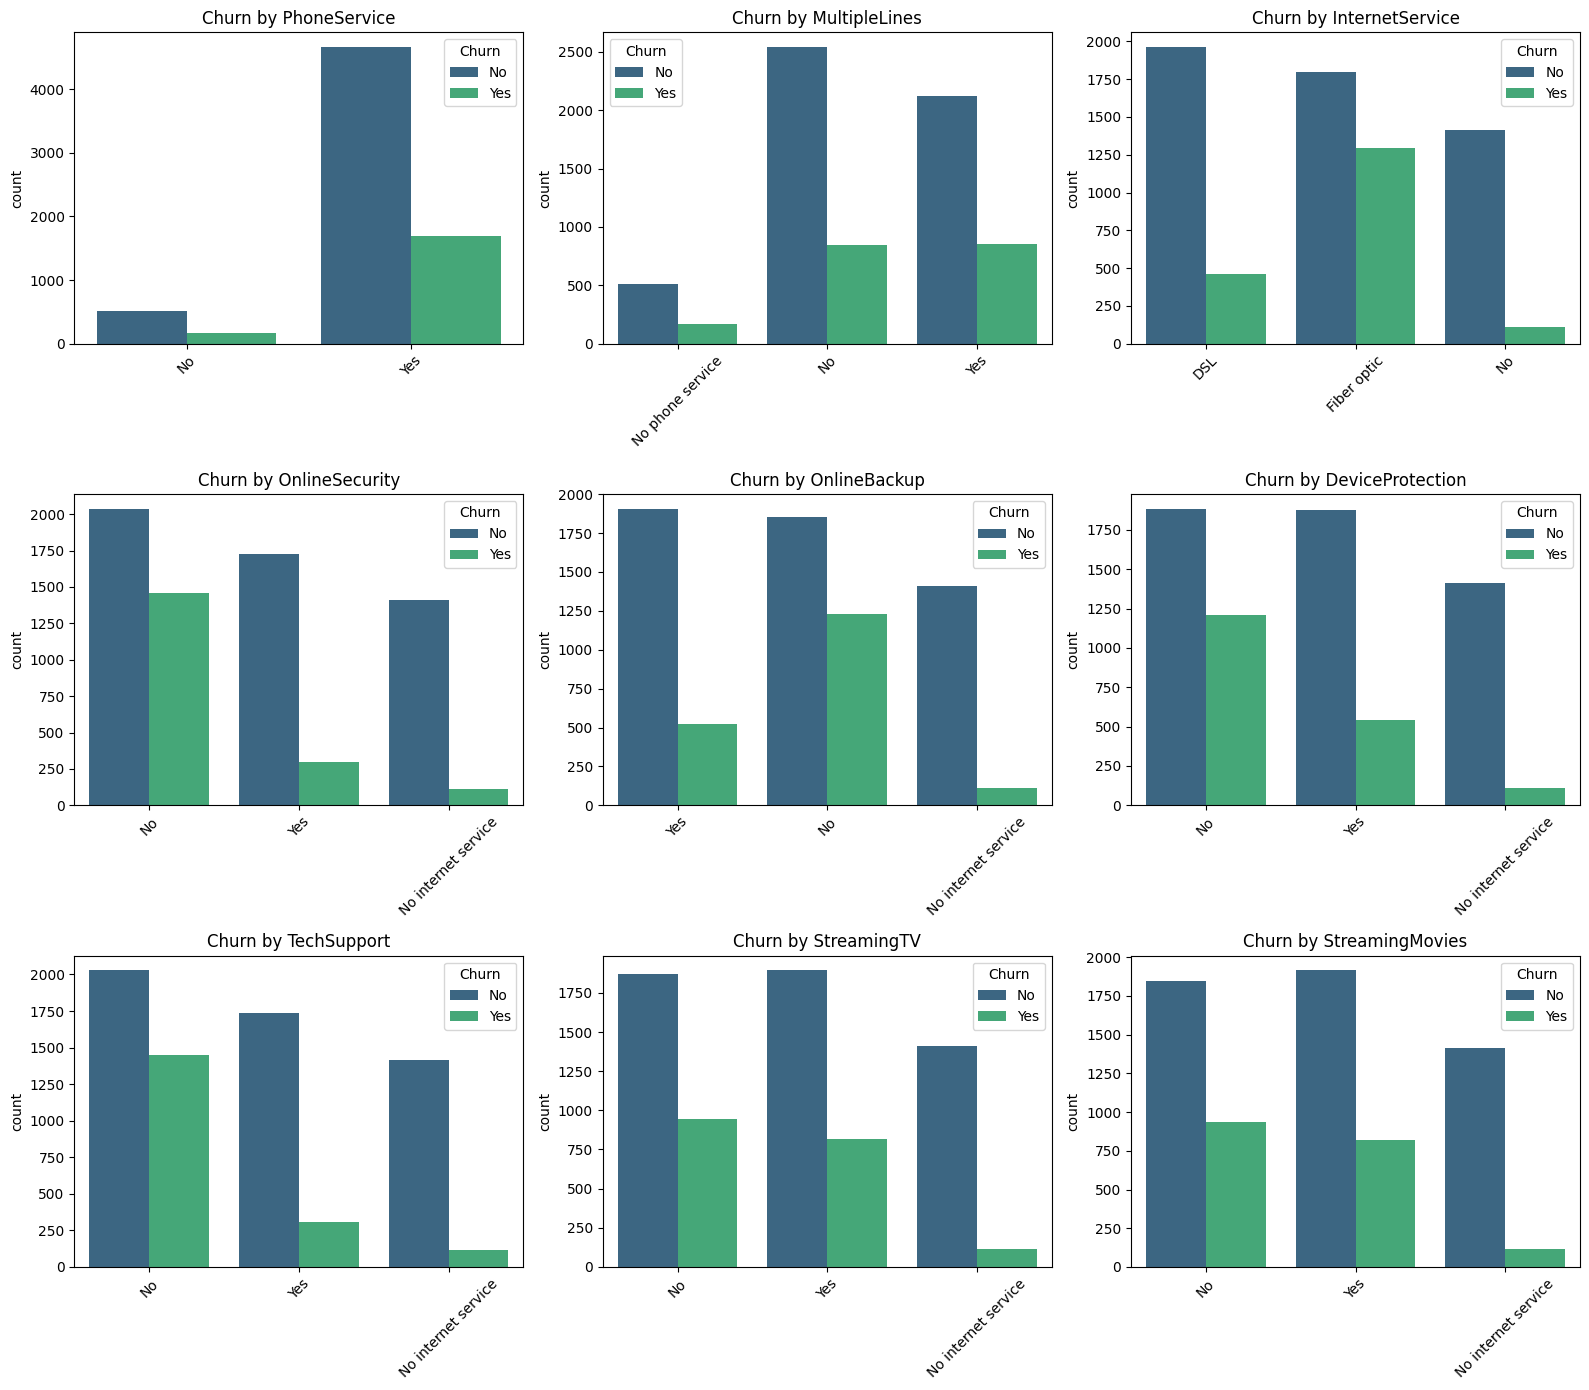

In [55]:
# List of columns to plot
cols = ['PhoneService', 'MultipleLines', 'InternetService',
        'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
        'TechSupport', 'StreamingTV', 'StreamingMovies']

# Set up the grid (3 rows, 3 columns)
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(16, 14))
axes = axes.flatten() # Flatten to 1D for easy looping

for i, col in enumerate(cols):
    sns.countplot(x=col, data=df, hue='Churn', ax=axes[i], palette='viridis')
    axes[i].set_title(f'Churn by {col}')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45) # Rotate labels if they overlap

# Adjust layout so titles don't overlap
plt.tight_layout()
plt.show()


#Based on the charts, users with Fiber optic internet and those without add-on services (like Online Security, Tech Support, or Online Backup) show significantly higher churn rates. In contrast, customers who have these security and support features enabled are much more likely to stay. Interestingly, the streaming services (TV and Movies) don't seem to impact churn as strongly as the core technical support features.

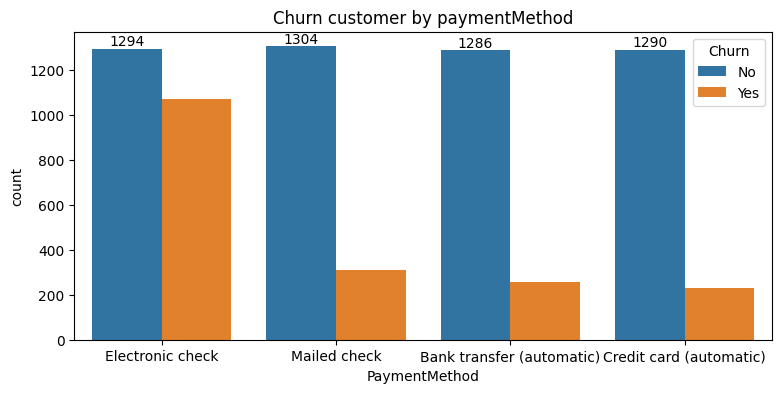

In [58]:
plt.figure(figsize = (9,4))
ax = sns.countplot(x=df["PaymentMethod"], data = df, hue= 'Churn')
ax.bar_label (ax.containers[0])
plt.title("Churn customer by paymentMethod")
plt.show()

#Cusomer id likely to churn when he is using Electroni check as apayment method
## **Executive Summary – Customer Churn Analysis**

This analysis evaluates customer churn behavior across a dataset of **7,043 telecom customers**, with the objective of identifying key risk drivers and informing data-driven retention strategies.

The overall churn rate stands at **26.54%**, meaning approximately **1 in every 4 customers leaves the company**, while **73.46% are retained**. This level of churn is significant and indicates a need for targeted intervention, particularly within high-risk customer segments.

### **Key Drivers of Churn**

**1. Customer Tenure (Lifecycle Risk)**

* Customers with **low tenure (0–12 months)** exhibit the **highest churn rates**, forming the majority of churned users.
* In contrast, customers with **long tenure (24+ months)** show significantly lower churn.
* This highlights a clear pattern: **churn risk declines as customer tenure increases**, making the **first year critical for retention efforts**.

**2. Contract Type (Commitment Level)**

* **Month-to-month contracts** have the **highest churn rate (~40–45%)**, making them the most vulnerable group.
* Customers on **one-year contracts** show moderate churn (~10–15%).
* Customers on **two-year contracts** have the **lowest churn (~2–5%)**.
* This demonstrates that **long-term contractual commitment reduces churn risk by up to 80–90% compared to month-to-month users**.

**3. Service Adoption (Value Perception)**

* Customers **without add-on services** (Online Security, Tech Support, Backup) churn at significantly higher rates.
* Customers who subscribe to **multiple services show reduced churn (often below 15–20%)**.
* This indicates that **service bundling increases perceived value and customer stickiness**.

**4. Internet Service Type**

* Customers using **Fiber Optic Internet** exhibit **higher churn rates (~40%+)** compared to DSL users (~15–20%).
* This suggests potential issues such as:

  * Higher pricing sensitivity
  * Service quality concerns
  * Mismatch between expectations and delivery

**5. Demographic Factors**

* **Senior Citizens** show a **higher churn rate (~40%)** compared to non-senior customers (~23%).
* **Gender** does not significantly impact churn (male and female churn rates are nearly equal at ~26–27%).

---

### **Behavioral Pattern Summary**

High churn probability is strongly associated with:

* **Short tenure (<12 months)**
* **Month-to-month contracts**
* **Limited or no add-on services**
* **Fiber optic internet usage**
* **Senior citizen segment**

---

### **Business Impact**

* Losing **26.54% of customers** represents a substantial revenue leakage risk.
* Since acquisition costs are typically higher than retention costs, reducing churn even by **5–10% could significantly improve profitability and customer lifetime value (CLV)**.

---

### **Strategic Recommendations**

To mitigate churn effectively, the company should focus on:

* **Early Lifecycle Engagement**

  * Strengthen onboarding and first-year experience to reduce early-stage churn.

* **Contract Conversion Strategy**

  * Incentivize migration from month-to-month plans to **long-term contracts**, potentially reducing churn by up to **80%**.

* **Service Bundling & Upselling**

  * Promote adoption of **value-added services**, increasing retention likelihood by **15–25%**.

* **Fiber Optic Service Optimization**

  * Investigate and address **pricing, quality, or expectation gaps** for fiber users.

* **Segment-Specific Retention**

  * Design targeted support and simplified service offerings for **senior customers**, a segment with ~40% churn risk.

---

### **Conclusion**

Customer churn is primarily driven by **low engagement, weak contractual commitment, and insufficient service integration**. By targeting high-risk segments—particularly **new customers, month-to-month users, and low-service adopters**—the company can reduce churn, improve retention rates, and drive sustainable revenue growth.
